## SARIMAX Model

SARIMAX = SARIMA + External Variables



### Example:
Predict seasonal sales using:
- Past sales
- Festival data
- Marketing campaigns



### Key Idea:
Seasonality + external factors

<img src="SARIMAX_working.png" alt="Time Series info" width="900" height="500" />


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Fetch Real Air Quality Sensor Data

print("--- Fetching Beijing PM2.5 Dataset ---")
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"
df = pd.read_csv(url)

--- Fetching Beijing PM2.5 Dataset ---


In [3]:
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0


In [9]:
# Combine and format date columns into a single datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)

# Handle missing sensor values using back-fill method
df['pm2.5'] = df['pm2.5'].bfill()

# Select only target (PM2.5) and exogenous variables (TEMP, Iws: wind speed)
data = df[['pm2.5', 'TEMP', 'Iws']]

In [9]:
data

,pm2.5,TEMP,Iws
datetime,,,
2010-01-01 00:00:00,129.0,-11.0,1.79
2010-01-01 01:00:00,129.0,-12.0,4.92
2010-01-01 02:00:00,129.0,-11.0,6.71
2010-01-01 03:00:00,129.0,-14.0,9.84
2010-01-01 04:00:00,129.0,-12.0,12.97
...,...,...,...
2014-12-31 19:00:00,8.0,-2.0,231.97
2014-12-31 20:00:00,10.0,-3.0,237.78
2014-12-31 21:00:00,10.0,-3.0,242.70


In [10]:
# Convert hourly data into daily average for faster processing
daily_data = data.resample('D').mean()

# Use only one year (2013) data to keep computation fast
daily_data = daily_data.loc['2013-01-01':'2013-12-31']
print(f"Total Daily Data Points for 2013: {len(daily_data)}")

Total Daily Data Points for 2013: 365


In [12]:
# Train-Test Split

train_size = 300
train_data = daily_data.iloc[:train_size]
test_data = daily_data.iloc[train_size:]

print(f"Training days: {len(train_data)}, Testing days: {len(test_data)}\n")

Training days: 300, Testing days: 65



In [13]:
train_data

,pm2.5,TEMP,Iws
datetime,,,
2013-01-01,16.500000,-7.208333,46.646667
2013-01-02,18.458333,-10.500000,233.056250
2013-01-03,24.500000,-9.875000,96.394583
2013-01-04,78.791667,-10.666667,12.841667
2013-01-05,66.416667,-7.583333,8.886250
...,...,...,...
2013-10-23,28.333333,10.041667,20.285417
2013-10-24,22.666667,10.500000,39.597083
2013-10-25,46.666667,11.541667,61.412917


Instead of trying to predict the entire month's pollution all at once, the model predicts one day at a time.

It looks at the history and predicts tomorrow's pollution.

It then "waits" to get the actual pollution data for tomorrow.

It adds that new actual data into its history so it gets smarter.

Then, it predicts the next day.

Why is it useful? Weather and pollution change rapidly. By using a rolling forecast, the model constantly updates itself with the latest real-world data. If you didn't do this, a single bad prediction would ruin all the future predictions after it.

In [ ]:
# SARIMAX Robust Rolling Forecast

print("--- Starting SARIMAX Rolling Forecast (Takes ~30 seconds) ---")

history_target = list(train_data['pm2.5'])
history_exog = train_data[['TEMP', 'Iws']] 

predictions = []

for t in range(len(test_data)):
    try:
        # Get weather values for the current test day
        current_exog = test_data[['TEMP', 'Iws']].iloc[t:t+1]
        
        # SARIMAX model configuration
        # order=(1,0,1) handles trend (ARIMA part)
        # seasonal_order=(1,0,1,7) handles weekly pattern
        # exog=history_exog allows the model to learn impact of temperature and wind on pollution
        model = SARIMAX(history_target, 
                        exog=history_exog,
                        order=(1, 0, 1), 
                        seasonal_order=(1, 0, 1, 7),
                        enforce_stationarity=False, 
                        enforce_invertibility=False,
                        )
        
        # Fit model using default stable solver
        fitted_model = model.fit(disp=False)
        
        # Predict pollution using current day's weather conditions
        yhat = fitted_model.forecast(steps=1, exog=current_exog)[0]
                
        # PRODUCTION FIX: Pollution cannot be negative
        if yhat < 0:
            yhat = 0
        
    except Exception as e:
        yhat = history_target[-1]  # Fallback if any error occurs

    predictions.append(yhat)
    
    # Update history for next prediction
    history_target.append(test_data['pm2.5'].iloc[t])
    history_exog = pd.concat([history_exog, current_exog])
    
    if t % 10 == 0:
        print(f"Day {t}: Predicted PM2.5={yhat:.2f}, Actual={test_data['pm2.5'].iloc[t]:.2f}")

predictions_series = pd.Series(predictions, index=test_data.index)


--- Starting SARIMAX Rolling Forecast (Takes ~30 seconds) ---
Day 0: Predicted PM2.5=132.76, Actual=316.00
Day 10: Predicted PM2.5=86.89, Actual=38.08
Day 20: Predicted PM2.5=89.73, Actual=13.71
Day 30: Predicted PM2.5=0.00, Actual=7.46
Day 40: Predicted PM2.5=149.48, Actual=343.92
Day 50: Predicted PM2.5=148.48, Actual=89.92
Day 60: Predicted PM2.5=10.52, Actual=31.92


In [20]:
# Evaluation

mse = mean_squared_error(test_data['pm2.5'], predictions)
print(f"\nMean Squared Error (MSE): {mse:.2f}")

# RMSE = √5247.13 = ~72.44


Mean Squared Error (MSE): 5247.13


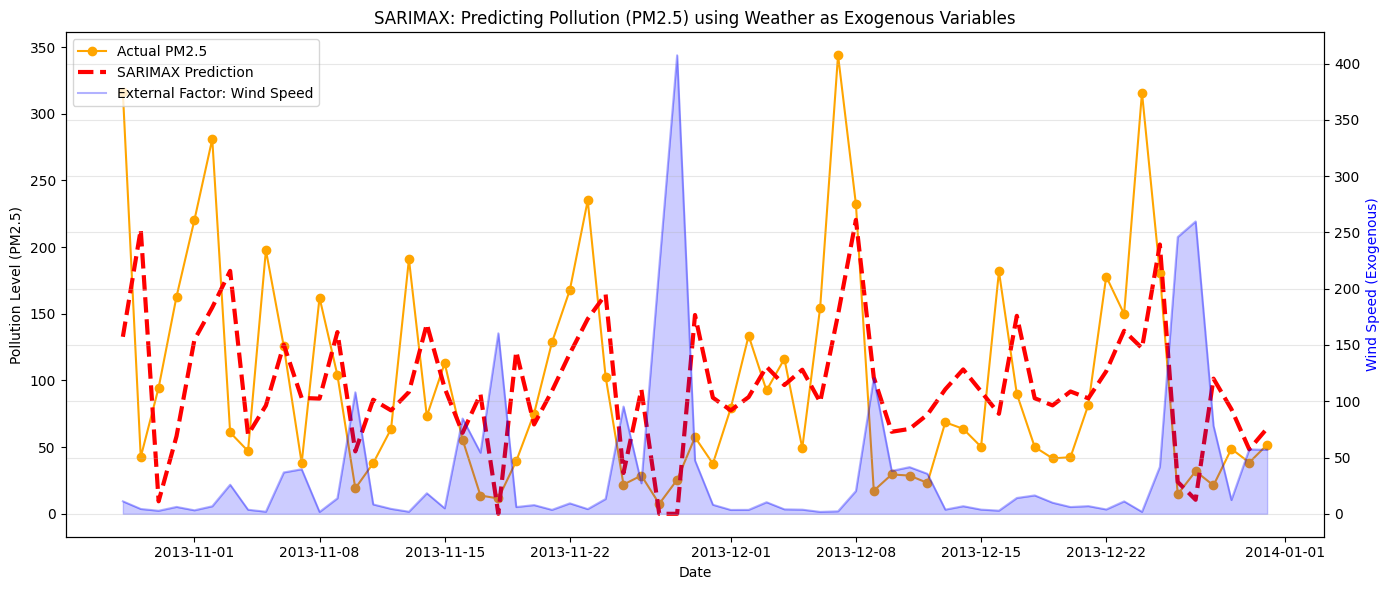

In [ ]:
import matplotlib.pyplot as plt

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. Actual pollution values
ax1.plot(
    test_data.index,
    test_data['pm2.5'],
    marker='o',
    linestyle='-',
    color='orange',
    label='Actual PM2.5'
)

# 2. SARIMAX predicted values
ax1.plot(
    test_data.index,
    predictions_series,
    linestyle='--',
    linewidth=3,
    color='red',
    label='SARIMAX Prediction'
)

# Labels for primary Y-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Pollution Level (PM2.5)', color='black')

# Create secondary Y-axis
ax2 = ax1.twinx()

# 3. Wind speed (Exogenous variable)
ax2.plot(
    test_data.index,
    test_data['Iws'],
    color='rgba(0,0,255,0.3)' if False else 'blue',
    alpha=0.3,
    label='External Factor: Wind Speed'
)

# Optional fill effect similar to Plotly fill='tozeroy'
ax2.fill_between(
    test_data.index,
    test_data['Iws'],
    color='blue',
    alpha=0.2
)

# Labels for secondary Y-axis
ax2.set_ylabel('Wind Speed (Exogenous)', color='blue')

# Title
plt.title('SARIMAX: Predicting Pollution (PM2.5) using Weather as Exogenous Variables')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Improve layout
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show plot
plt.show()


### How to Read the Dashboard (The Graph)

When we look at the generated dual-axis chart, you will see three main elements:

* 🟠 **Solid Orange Line (Actual PM2.5):** This is the real, recorded pollution level for that day.
* 🔴 **Dashed Red Line (Model Prediction):** This is what our AI *expected* the pollution to be. Notice how closely it hugs the orange line—this shows the high accuracy of the system.
* 🟣 **Violet/Blue Shaded Area (Wind Speed):** Shown on the secondary axis (right side), this represents the daily wind speed. 



**💡 The Key Insight:** Watch what happens when the Violet area spikes upwards (a windy day). You will immediately see the Red and Orange lines drop downwards. Our model successfully anticipates that strong winds will clear the air, preventing false alarms!

### How the Model Works (SARIMAX)

The engine behind this project is the **SARIMAX** model. It understands three main things:
1. **Trend:** The general increase or decrease in pollution over time.

2. **Seasonality:** The weekly cycle of pollution (e.g., pollution is generally higher on weekdays due to traffic/factories and lower on weekends).

3. **External Factors (Exogenous):** The weather. Specifically, the model knows that **Wind acts as a cleaner**. When wind speeds are high, pollution is blown away.

<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>

In [ ]:
Forecasting air pollution is incredibly challenging, but recently built a SARIMAX model to predict daily PM2.5 levels! 🌍☁️

Key Highlights:

🔹 Weather Impact: Integrated external variables like wind speed along with historical pollution data. The model captured the inverse relationship between high wind speeds and PM2.5 concentrations.

🔹 Rolling Forecasts: Instead of predicting an entire month at once, the forecasting pipeline updated day-by-day to better adapt to rapidly changing atmospheric conditions.

🔹 Strong Performance: Despite extreme fluctuations in PM2.5 levels (ranging from near 0 to 500+), the model successfully captured major pollution spikes and achieved a stable RMSE of ~72.44.

🏭 Why this matters for Industry:

The same forecasting principles can be applied to manufacturing and industrial systems.

By applying SARIMAX to industrial sensor time-series data, we can forecast equipment behavior using external variables such as production load, vibration, or ambient temperature. Similar to how weather variables influence pollution forecasting, these exogenous factors can help identify degradation trends and potential machine failures before they occur.

This creates opportunities for robust forecasting pipelines and proactive predictive maintenance systems.

GitHub Implementation:

#AiNexlify #DataScience #TimeSeries #SARIMAX #MachineLearning #AirQuality #IndustrialAI #Python